<div style='font-size: 200%; line-height: 2;'>
To participate, you'll need to git clone (or download the .zip from GitHub):

<p>https://github.com/scikit-image/skimage-tutorials</p>
</div>

<p>You can do that in git using:</p>

<pre>git clone --depth=1 https://github.com/scikit-image/skimage-tutorials</pre>

<div style='font-size: 200%; line-height: 1.5;'>
If you have already cloned the material, please issue `git pull` now and reload the notebook to ensure that you have the latest updates.
</div>

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Images are numpy arrays

Images are represented in ``scikit-image`` using standard ``numpy`` arrays.  This allows maximum inter-operability with other libraries in the scientific Python ecosystem, such as ``matplotlib`` and ``scipy``.

Let's see how to build a grayscale image as a 2D array:

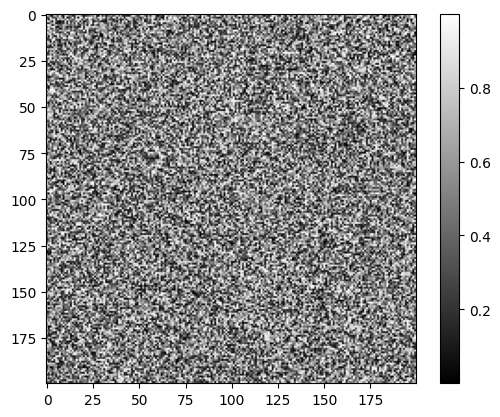

In [20]:
#Generates a random grayscale image of size 200x200 and displays it using matplotlib.
import numpy as np
from matplotlib import pyplot as plt

random_image = np.random.random([200, 200]) #This creates a 200x200 array filled with random values between 0 and 1.

plt.imshow(random_image, cmap='gray') #This displays the array as an image, with the cmap='gray' argument specifying that the image should be shown in grayscale.
plt.colorbar(); # Adds a color bar to the side of the image to indicate the range of values (from 0 to 1 in this case).




The same holds for "real-world" images:

Type: <class 'numpy.ndarray'>
dtype: uint8
shape: (303, 384)


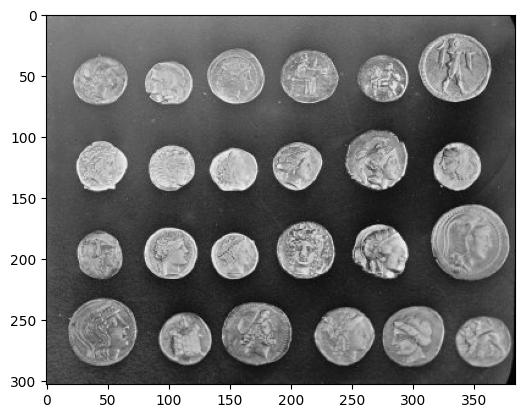

In [21]:
from skimage import data

coins = data.coins()

print('Type:', type(coins))
print('dtype:', coins.dtype)
print('shape:', coins.shape) #This returns the shape of the image (height, width)

plt.imshow(coins, cmap='gray'); #This uses matplotlib to display the image with a grayscale colormap (cmap='gray'). The imshow function will render the image as a plot.

A color image is a 3D array, where the last dimension has size 3 and represents the red, green, and blue channels:

Shape: (300, 451, 3)
Values min/max: 0 231


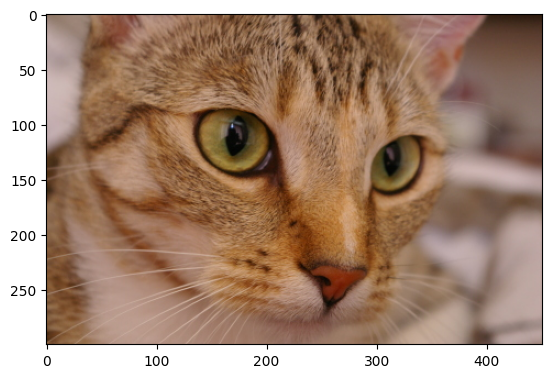

In [22]:
cat = data.chelsea() #The chelsea() function returns the image as a 3D numpy array (height x width x color channels).
print("Shape:", cat.shape)
print("Values min/max:", cat.min(), cat.max())

plt.imshow(cat);

These are *just NumPy arrays*. E.g., we can make a red square by using standard array slicing and manipulation:

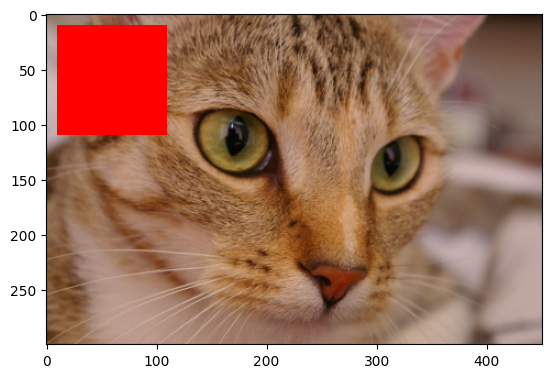

In [23]:
#This selects a rectangular region of the image. It selects pixels starting from row 10 to row 110 and from column 10 to column 110.
#The : in the last position selects all three color channels (RGB).
cat[10:110, 10:110, :] = [255, 0, 0]  # [red, green, blue]
plt.imshow(cat);

Images can also include transparent regions by adding a 4th dimension, called an *alpha layer*.

### Other shapes, and their meanings

|Image type|Coordinates|
|:---|:---|
|2D grayscale|(row, column)|
|2D multichannel|(row, column, channel)|
|3D grayscale (or volumetric) |(plane, row, column)|
|3D multichannel|(plane, row, column, channel)|

## Displaying images using matplotlib

In [24]:
from skimage import data

img0 = data.chelsea()
img1 = data.rocket()

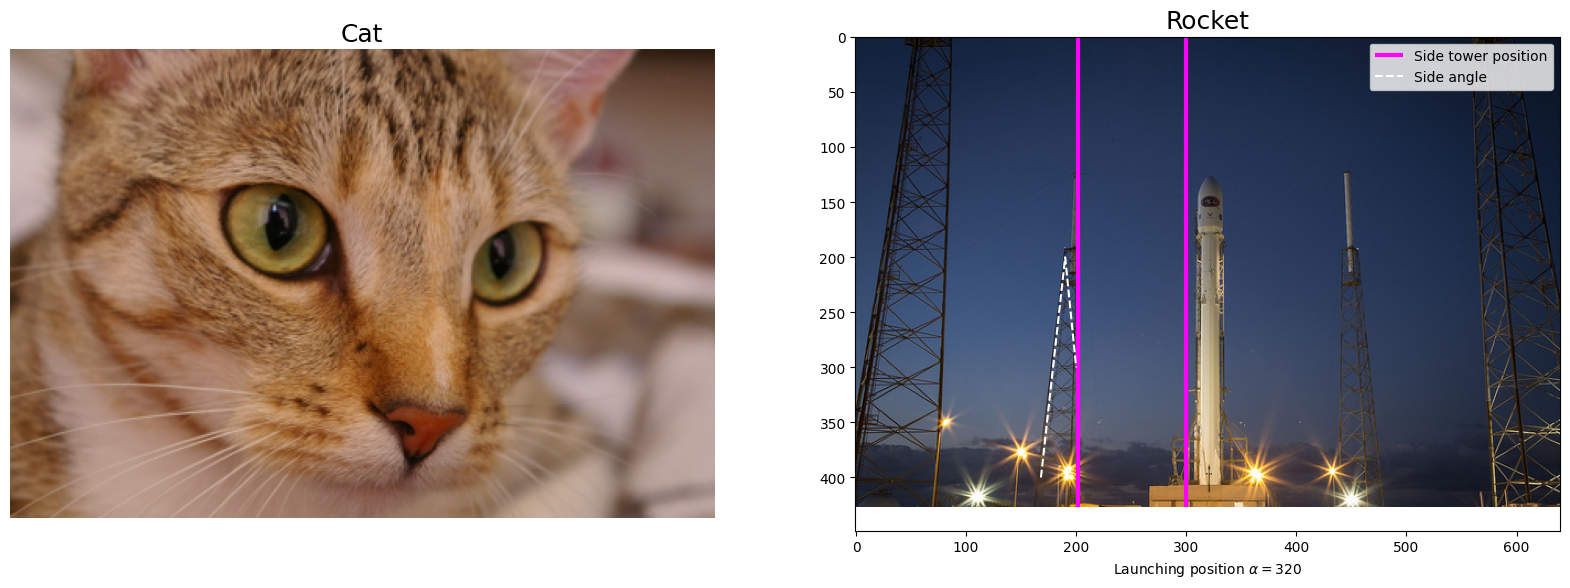

In [25]:
import matplotlib.pyplot as plt

f, (ax0, ax1) = plt.subplots(1, 2, figsize=(20, 10))

ax0.imshow(img0)
ax0.set_title('Cat', fontsize=18)
ax0.axis('off')

ax1.imshow(img1)
ax1.set_title('Rocket', fontsize=18)
ax1.set_xlabel(r'Launching position $\alpha=320$')

ax1.vlines([202, 300], 0, img1.shape[0], colors='magenta', linewidth=3, label='Side tower position')
ax1.plot([168, 190, 200], [400, 200, 300], color='white', linestyle='--', label='Side angle')

ax1.legend();

For more on plotting, see the [Matplotlib documentation](https://matplotlib.org/gallery/index.html#images-contours-and-fields) and [pyplot API](https://matplotlib.org/api/pyplot_summary.html).

## Data types and image values

In literature, one finds different conventions for representing image values:

```
  0 - 255   where  0 is black, 255 is white
  0 - 1     where  0 is black, 1 is white
```

``scikit-image`` supports both conventions--the choice is determined by the
data-type of the array.

E.g., here, I generate two valid images:

Linear0: float64 0.0 1.0
Linear1: uint8 0 255


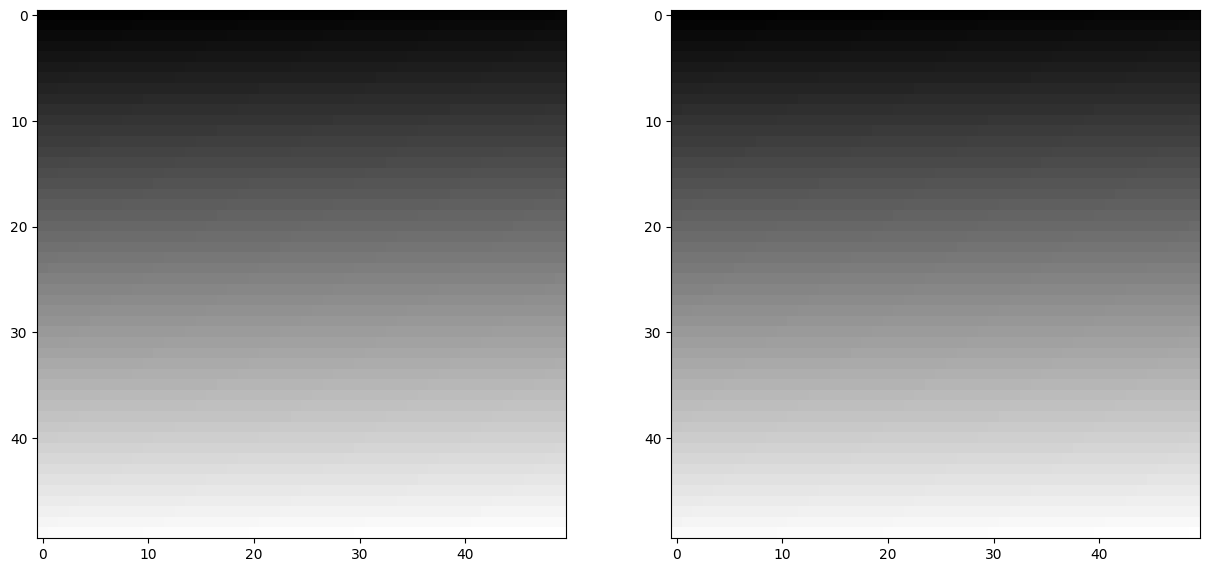

In [26]:
linear0 = np.linspace(0, 1, 2500).reshape((50, 50))
linear1 = np.linspace(0, 255, 2500).reshape((50, 50)).astype(np.uint8)

print("Linear0:", linear0.dtype, linear0.min(), linear0.max())
print("Linear1:", linear1.dtype, linear1.min(), linear1.max())

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(15, 15))
ax0.imshow(linear0, cmap='gray')
ax1.imshow(linear1, cmap='gray');

The library is designed in such a way that any data-type is allowed as input,
as long as the range is correct (0-1 for floating point images, 0-255 for unsigned bytes,
0-65535 for unsigned 16-bit integers).

You can convert images between different representations by using ``img_as_float``, ``img_as_ubyte``, etc.:

In [27]:
from skimage import img_as_float, img_as_ubyte

image = data.chelsea()

image_ubyte = img_as_ubyte(image)
#Converts the image to an 8-bit unsigned integer format (uint8). This means the pixel values will be scaled to the range [0, 255]
image_float = img_as_float(image)
#Converts the image to a floating point format (float64), where pixel values are scaled to the range [0.0, 1.0].

print("type, min, max:", image_ubyte.dtype, image_ubyte.min(), image_ubyte.max())
print("type, min, max:", image_float.dtype, image_float.min(), image_float.max())
print()
print("231/255 =", 231/255.)

type, min, max: uint8 0 231
type, min, max: float64 0.0 0.9058823529411765

231/255 = 0.9058823529411765


Your code would then typically look like this:

```python
def my_function(any_image):
   float_image = img_as_float(any_image)
   # Proceed, knowing image is in [0, 1]
```

We recommend using the floating point representation, given that
``scikit-image`` mostly uses that format internally.

## Image I/O

Mostly, we won't be using input images from the scikit-image example data sets.  Those images are typically stored in JPEG or PNG format.  Since scikit-image operates on NumPy arrays, *any* image reader library that provides arrays will do.  Options include imageio, matplotlib, pillow, etc.

scikit-image conveniently wraps many of these in the `io` submodule, and will use whichever of the libraries mentioned above are installed:

<class 'numpy.ndarray'>
uint8
(300, 225, 3)
0 255


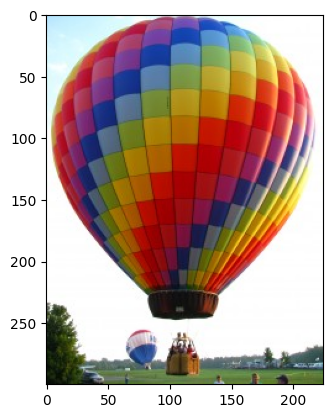

In [28]:
from skimage import io

image = io.imread('../images/balloon.jpg')
#This function from skimage.io reads an image from the given path (in this case, '../images/balloon.jpg') and loads it into a numpy array.
#The image is typically represented as a 3D numpy array for color images (height x width x color channels), with the color channels being usually in RGB format (Red, Green, Blue).

print(type(image))
print(image.dtype)
print(image.shape)
print(image.min(), image.max())

plt.imshow(image);

We also have the ability to load multiple images, or multi-layer TIFF images:

In [44]:
ic = io.ImageCollection('../images/*.png:../images/*.jpg')
#Allows me to load a collection of images into memory.
#Uses glob pattern matching to search for all files that match the patterns:

print('Type:', type(ic))

ic.files
#Print a list of the files loaded in previous function

# Search for 'cat.jpg' in the list of files
cat_file = [file for file in ic.files if 'cat.jpg' in file]
# Print the result
if cat_file:
    print(f"Found cat.jpg in the collection: {cat_file[0]}")
else:
    print("cat.jpg not found in the collection.")

Type: <class 'skimage.io.collection.ImageCollection'>
cat.jpg not found in the collection.


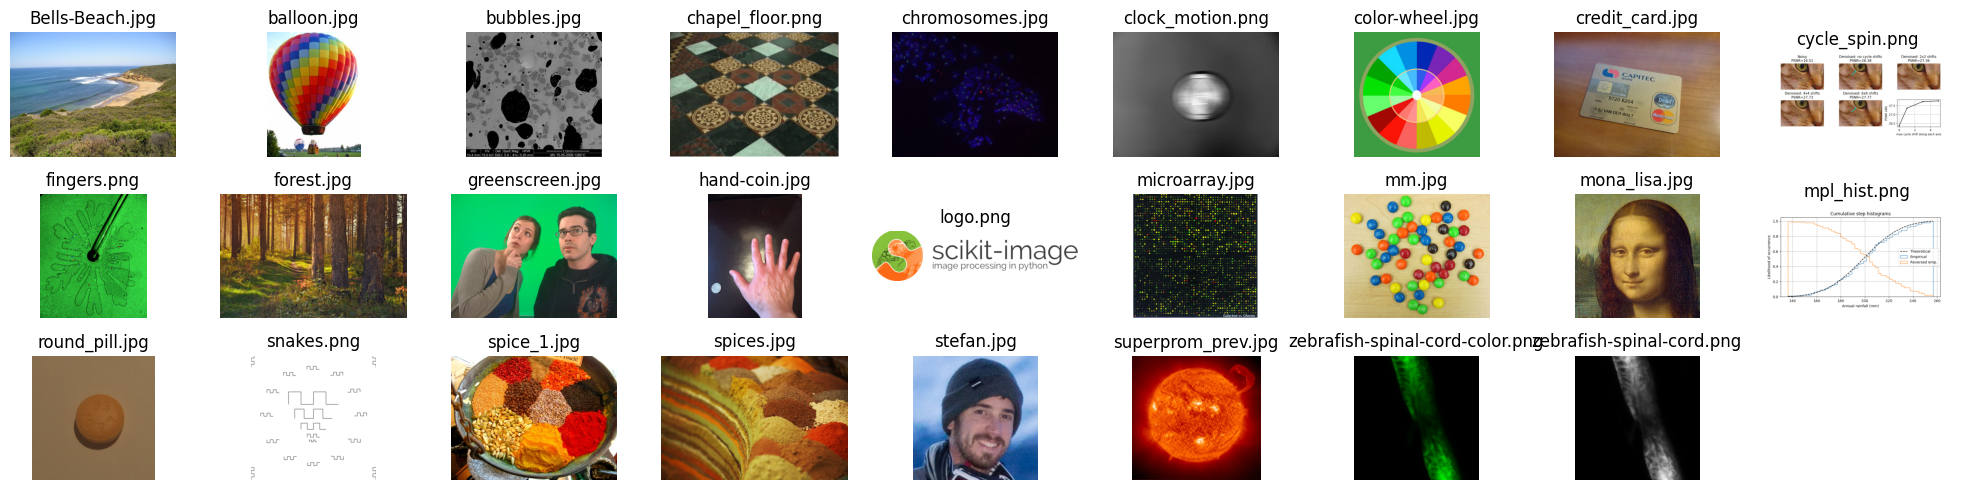

In [31]:
import os
#Display all the images from the ImageCollection (ic) in a grid layout using matplotlib

f, axes = plt.subplots(nrows=3, ncols=len(ic) // 3 + 1, figsize=(20, 5))
#Creating a grid of subplots with 3 rows (nrows=3) and the number of columns calculated based on the number of images in ic (len(ic) // 3 + 1).
#Len calculates the number of images in the image collection from earlier, so the number of columns is being set equal to the number of images in the ic

# subplots returns the figure and an array of axes
# we use `axes.ravel()` to turn these into a list
axes = axes.ravel()

for ax in axes:
    ax.axis('off')

for i, image in enumerate(ic):
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(os.path.basename(ic.files[i]))
    
plt.tight_layout()

### Aside: `enumerate`

`enumerate` gives us each element in a container, along with its position.

In [32]:
animals = ['cat', 'dog', 'leopard']

In [33]:
for i, animal in enumerate(animals):
    print('The animal in position {} is {}'.format(i, animal))

    #Allows me to loop over an iterable (like a list of animals given above) and get both the index (i) and the value (animal) of each item in that iterable.

The animal in position 0 is cat
The animal in position 1 is dog
The animal in position 2 is leopard


## <span class="exercize">Exercise: draw the letter H</span>

Define a function that takes as input an RGB image and a pair of coordinates (row, column), and returns a copy with a green letter H overlaid at those coordinates. The coordinates point to the top-left corner of the H.

The arms and strut of the H should have a width of 3 pixels, and the H itself should have a height of 24 pixels and width of 20 pixels.

Start with the following template:

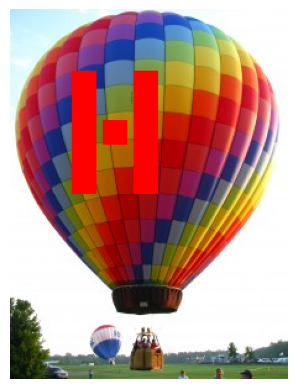

In [34]:
import matplotlib.pyplot as plt 
from skimage import io

def draw_H(image, coords, color=(0, 255, 0), height = 50, width = 20):
    image = io.imread('../images/balloon.jpg')
    #Reads an image from the given path
    coords = (1,1)
    #Define coordinates for the "H"
    output_image = draw_H(image, coords, color=(255, 0, 0))
    #Draw the "H" on the image
    out = image.copy()
    #Makes a copy of the image so if I mess up I still have the original image
    
# Display the result
plt.imshow(output_image)
plt.axis('off')  # Hide axes for better visualization
plt.show()
    


import matplotlib.pyplot as plt
from skimage import io

# Define the function to draw "H"
def draw_H(image, coords, color=(0, 255, 0), height=100, width=20):
    out = image.copy()  # Make a copy of the image

    x, y = coords  # Unpack the coordinates (top-left corner)

    # Vertical lines
    out[y:y + height, x:x + width] = color  # Left vertical line
    out[y:y + height, x + width + 30:x + width + 30 + width] = color  # Right vertical line

    # Horizontal line in the middle
    middle_y = y + height // 2
    out[middle_y - width // 2:middle_y + width // 2, x + width + 5:x + width + 5 + 20] = color  # Horizontal line

    return out

# Main code
image = io.imread('../images/balloon.jpg')  # Read the image from file
coords = (50, 50)  # Define coordinates for the "H"

# Call the draw_H function to draw "H" on the image
output_image = draw_H(image, coords, color=(255, 0, 0))  # Red color for the "H"

# Display the result
plt.imshow(output_image)
plt.axis('off')  # Hide axes for better visualization
plt.show()


Test your function like so:

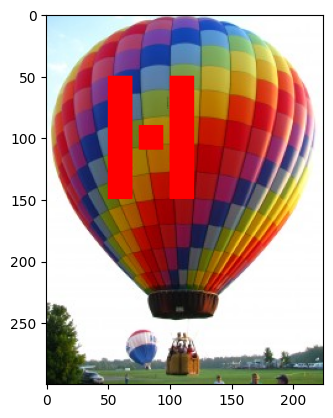

In [45]:
import matplotlib.pyplot as plt
from skimage import io


def draw_H(image, coords, color=(0, 255, 0), height = 50, width = 20):
    image = io.imread('../images/cat.jpg')
    #Reads an image from the given path
    coords = (1,1)
    #Define coordinates for the "H"
    output_image = draw_H(image, coords, color=(255, 0, 0))
    #Draw the "H" on the image
    out = image.copy()
    #Makes a copy of the image so if I mess up I still have the original image
    

plt.imshow(output_image);

## <span class="exercize">Exercise: visualizing RGB channels</span>

Display the different color channels of the image along (each as a gray-scale image).  Start with the following template:

In [52]:
import skimage as io
image = plt.imread('../images/Bells-Beach.jpg')
image = data.chelsea()


print(image.shape)

(300, 451, 3)


In [55]:
from skimage import io

# Use io.imread instead
image = io.imread('../images/Bells-Beach.jpg')

# Check the dtype and shape again
print("Image dtype:", image.dtype)  # Should be uint8 or float32
print("Image shape:", image.shape)


Image dtype: uint8
Image shape: (960, 1280, 3)


Image dtype: uint8
Image shape: (960, 1280, 3)


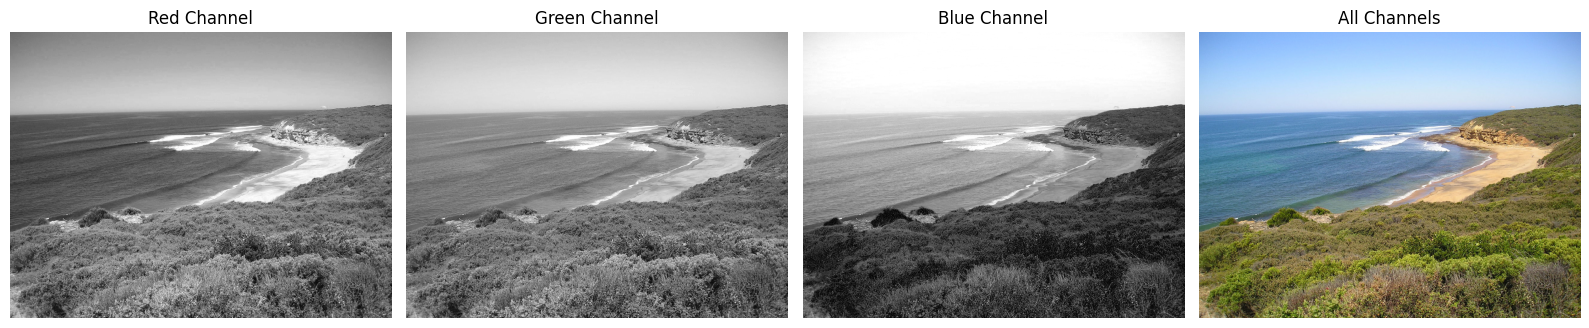

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Read the image (pixel values will be in range 0-255)
image = plt.imread('../images/Bells-Beach.jpg')

# Check the image dtype and shape to confirm
print("Image dtype:", image.dtype)  # Should be uint8
print("Image shape:", image.shape)  # Should be (height, width, 3)

# --- Assign each color channel to a different variable ---
r = image[..., 0]  # Red channel (first channel)
g = image[..., 1]  # Green channel (second channel)
b = image[..., 2]  # Blue channel (third channel)

# --- Display the image and r, g, b channels ---

# Create subplots to display the individual channels
f, axes = plt.subplots(1, 4, figsize=(16, 5))

# Turn off axis for each subplot for better visualization
for ax in axes:
    ax.axis('off')

# Unpack the axes for each subplot
(ax_r, ax_g, ax_b, ax_color) = axes

# Display the red channel
ax_r.imshow(r, cmap='gray')
ax_r.set_title('Red Channel')

# Display the green channel
ax_g.imshow(g, cmap='gray')
ax_g.set_title('Green Channel')

# Display the blue channel
ax_b.imshow(b, cmap='gray')
ax_b.set_title('Blue Channel')

# --- Stack the R, G, B layers again to form a color image ---
# np.stack combines the R, G, B layers along the third axis (axis=2)
ax_color.imshow(np.stack([r, g, b], axis=2))
ax_color.set_title('All Channels')

# Show the plots
plt.tight_layout()
plt.show()


Now, take a look at the following R, G, and B channels.  How would their combination look? (Write some code to confirm your intuition.)

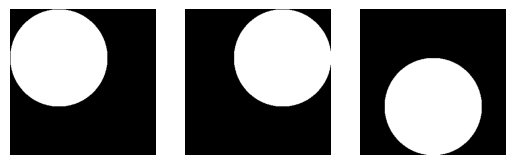

In [57]:
#Create 3 separate images (red, green, and blue channels) and filling them with circular shapes using the draw.disk() function from skimage.draw. These circles are drawn on the red, green, and blue images, respectively, with each circle representing the intensity of that color in the corresponding channel.
from skimage import draw

red = np.zeros((300, 300)) #creates an empty image (300x300) intialized with zeros
green = np.zeros((300, 300))
blue = np.zeros((300, 300))

r, c = draw.disk(center=(100, 100), radius=100)
red[r, c] = 1

#r: The row indices (vertical axis), corresponding to the pixels inside the disk.
#c: The column indices (horizontal axis), corresponding to the pixels inside the disk.

r, c = draw.disk(center=(100, 200), radius=100)
green[r, c] = 1

r, c = draw.disk(center=(200, 150), radius=100)
blue[r, c] = 1

f, axes = plt.subplots(1, 3)
for (ax, channel) in zip(axes, [red, green, blue]):
    ax.imshow(channel, cmap='gray')
    ax.axis('off')

## Exercise: Convert to grayscale ("black and white")

The *relative luminance* of an image is the intensity of light coming from each point. Different colors contribute differently to the luminance: it's very hard to have a bright, pure blue, for example. So, starting from an RGB image, the luminance is given by:

$$
Y = 0.2126R + 0.7152G + 0.0722B
$$

Use Python 3.5's matrix multiplication, `@`, to convert an RGB image to a grayscale luminance image according to the formula above.

Compare your results to that obtained with `skimage.color.rgb2gray`.

Change the coefficients to 1/3 (i.e., take the mean of the red, green, and blue channels, to see how that approach compares with `rgb2gray`).

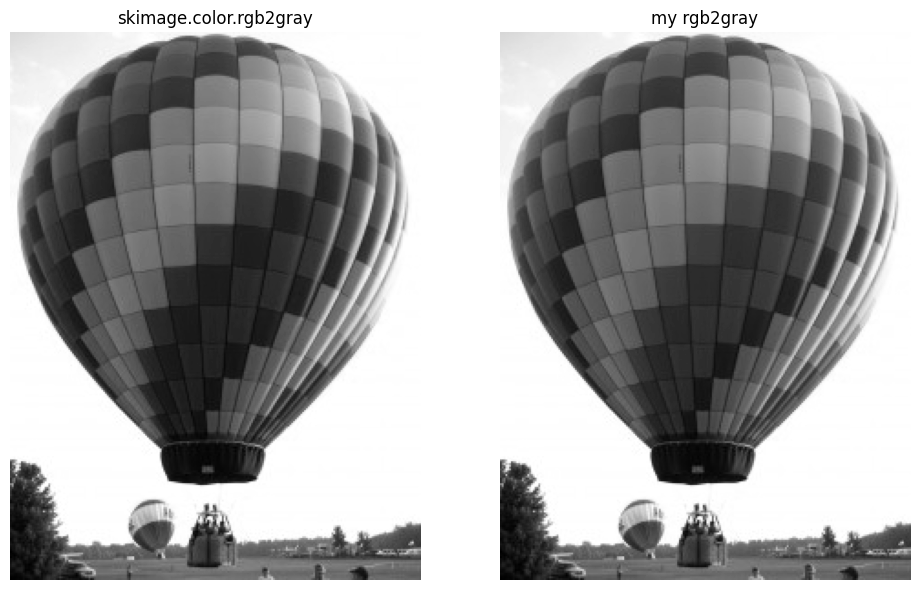

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import color, img_as_float, io

# Read the image and convert to float (0-1 range)
image = img_as_float(io.imread('../images/balloon.jpg'))

# Convert using skimage's built-in function
gray = color.rgb2gray(image)

# --- Implementing custom rgb2gray ---
def my_rgb2gray(rgb_image):
    # Apply the standard RGB to grayscale formula
    return 0.2989 * rgb_image[..., 0] + 0.5870 * rgb_image[..., 1] + 0.1140 * rgb_image[..., 2]

# Convert the image to grayscale using your custom method
my_gray = my_rgb2gray(image)

# --- Display the results ---
f, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 6))

# Display the grayscale images
ax0.imshow(gray, cmap='gray')
ax0.set_title('skimage.color.rgb2gray')

ax1.imshow(my_gray, cmap='gray')
ax1.set_title('my rgb2gray')

# Hide axes for better visualization
for ax in (ax0, ax1):
    ax.axis('off')

plt.tight_layout()
plt.show()
